#Introduction to Regression with Neural Networks in Tensorflow

There are many definitions for a regression problem but in our case, we are going to simplify it:predicting a numerical variable based on some other combination of variables, even shorter... predicting a number.


In [24]:
#Import TensorFlow
import tensorflow as tf
print(tf.__version__)

2.19.0


##Creating data to view and fit

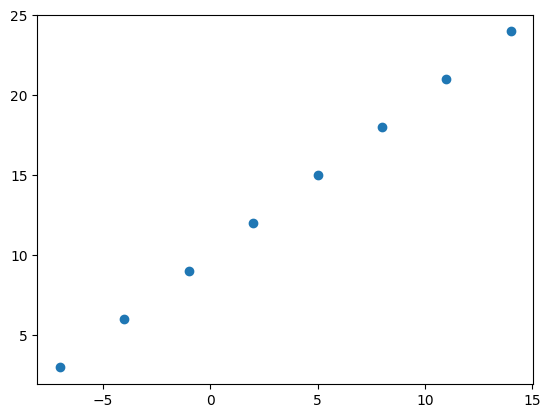

In [25]:
import numpy as np
import matplotlib.pyplot as plt
#Create features
X = np.array([-7.0,-4.0,-1.0,2.0,5.0,8.0,11.0,14.0])

#create labels
y = np.array([3.0,6.0,9.0,12.0,15.0, 18.0,21.0,24.0])

#Visualize it
plt.scatter(X, y);

In [26]:
y == X + 10

array([ True,  True,  True,  True,  True,  True,  True,  True])

##Input and Output shapes

In [27]:
# Create a demo tensor for our housing price prediction problem
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([939700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [28]:
X[0],y[0]

(np.float64(-7.0), np.float64(3.0))

In [29]:
X[1],y[1]

(np.float64(-4.0), np.float64(6.0))

In [30]:
input_shape = X.shape
output_shape = y.shape
input_shape, output_shape

((8,), (8,))

In [31]:
# Turn our Numpy arrays into tensors
X = tf.cast(tf.constant(X), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)
X, y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [32]:
input_shape = X[0].shape
output_shape = y[0].shape
input_shape, output_shape


(TensorShape([]), TensorShape([]))

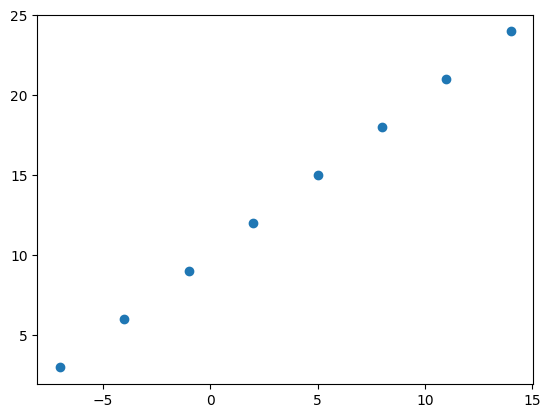

In [33]:
plt.scatter(X,y)

## Steps in modelling with TensorFlow


1. **Creating a mode**l - define the input and output layers, as well as the hidden layers of a deep learning model.
2. **Compiling a model** - define the loss function (in others words, the function which tells our model how wrong it is) and the optimizer (tells our model how to improve the patterns its learning) and evaluation metricsv(what we can use to interpret the performance of our model).
3. **fitting a model** - letting the model try to find patterns between X & y(features and labels)

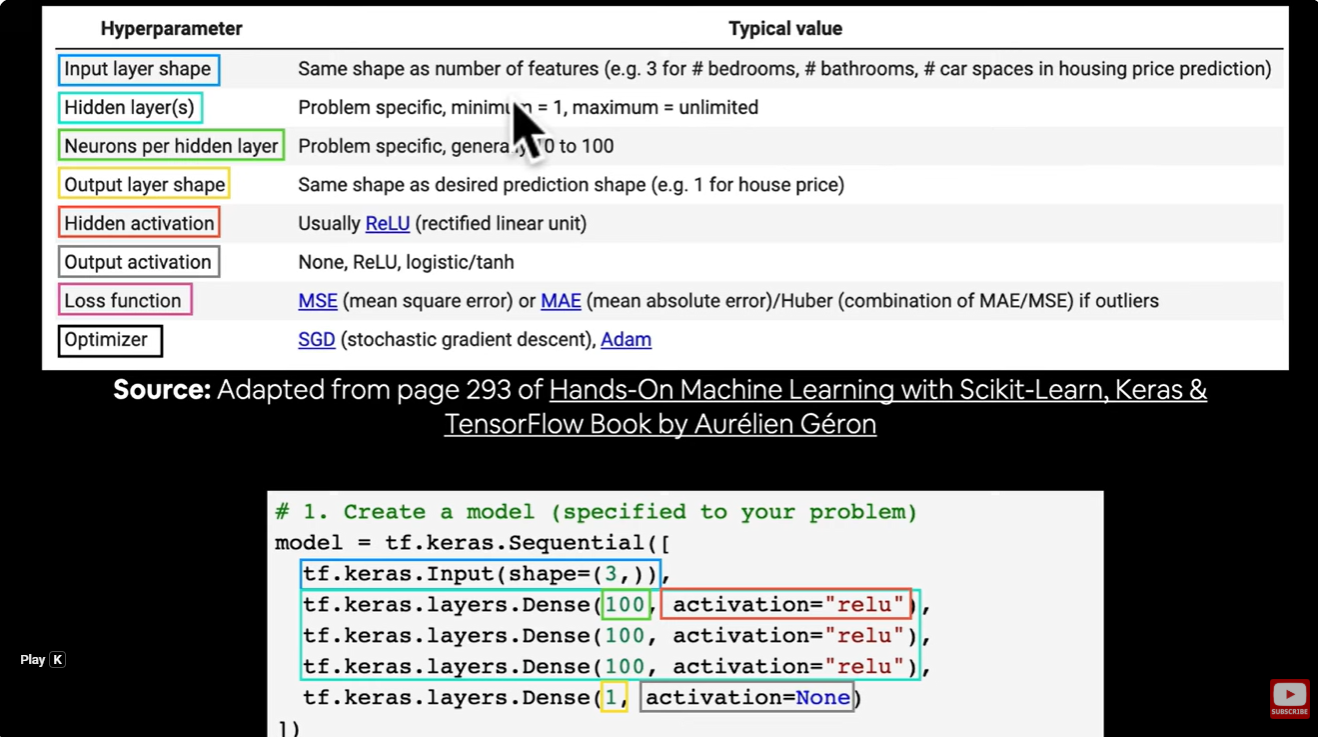

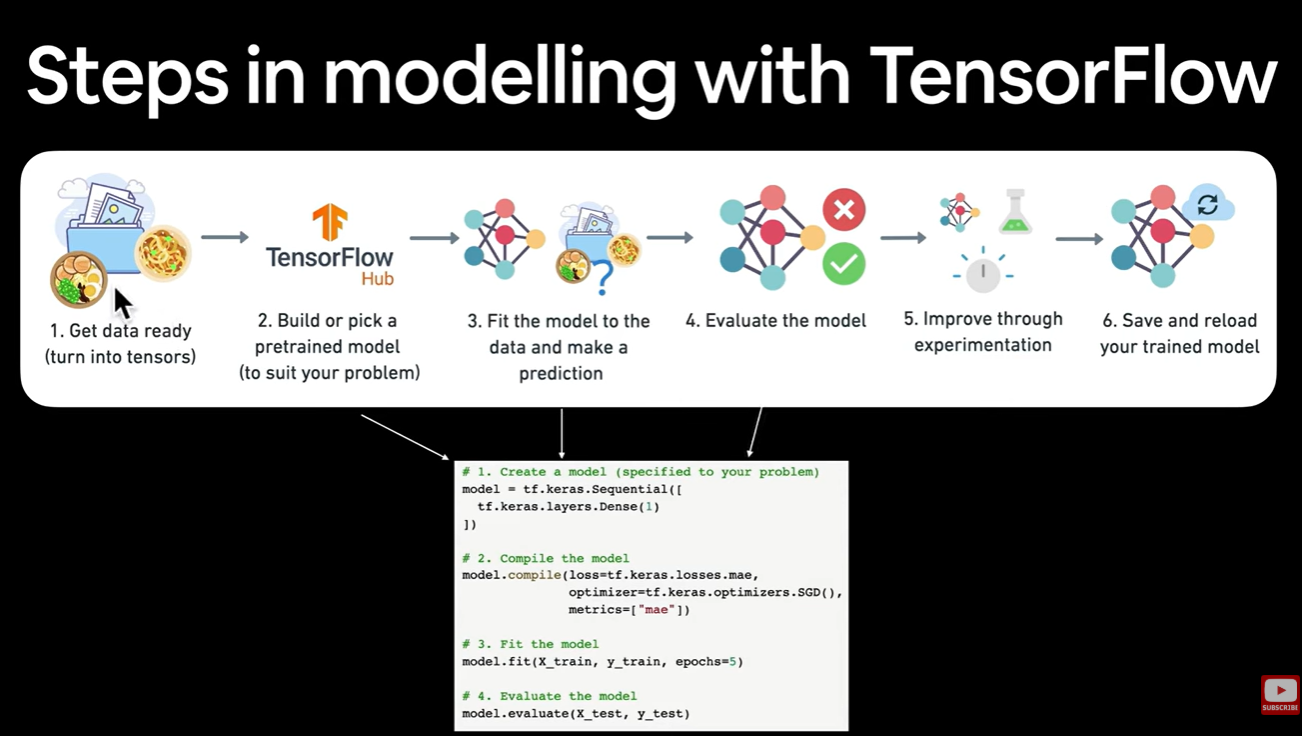

In [34]:
#set random seed
tf.random.set_seed(42)

# 1. Create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. Compile the model
model.compile(
    loss=tf.keras.losses.mae, # mae is short for mean absolute error
    optimizer=tf.keras.optimizers.SGD(), # SGD is short for stochastic gradient descent
    metrics=["mae"]
)

# Reshape X to be 2-dimensional
X = tf.expand_dims(X, axis=-1)

#3. Fit the model
model.fit(X, y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 829ms/step - loss: 15.5095 - mae: 15.5095
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 15.2282 - mae: 15.2282
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 14.9571 - mae: 14.9571
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 14.8246 - mae: 14.8246
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 14.6921 - mae: 14.6921


In [35]:
# Try and make a prediction using our model
model.predict(tf.constant([[[17.0]]]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


array([[-5.320418]], dtype=float32)

### Steps in Improving a model with TensorFlow part 1

We can improve our model, by altering the steps we took to create a model

1. **Creating a model** - here we might add more layers, increase the number of hidden units (also called nuerons within each of the hiden layers, change the activation function of each layers
2. **Compiling a model** - here we might change the optimization function or perhaps the **learning rate** of the optimization function
3. **Fitting a model** - Here we might fit a model for more **epochs**(leave it training for longer) or on more data (give the model more examples to learn from).

In [36]:
# Let's rebuild our model

# 1. Create our model

model =tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])
# 3. Fit the model(this time we'll train for longer)
model.fit(X,y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - loss: 18.2789 - mae: 18.2789
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 17.9977 - mae: 17.9977
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 17.7164 - mae: 17.7164
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 17.4352 - mae: 17.4352
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 17.1539 - mae: 17.1539
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 16.8727 - mae: 16.8727
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 16.5914 - mae: 16.5914
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 16.3102 - mae: 16.3102
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 16.0289 - mae: 16.0289
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 15.7477 - mae: 15.7477
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 15.4664 - mae: 15.4664
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 15.1852 - mae: 15.1852
Epoch 13/100
1/1 ━━━━━━━

In [37]:
# Remind ourselves of the data
X,y


(<tf.Tensor: shape=(8, 1), dtype=float32, numpy=
 array([[-7.],
        [-4.],
        [-1.],
        [ 2.],
        [ 5.],
        [ 8.],
        [11.],
        [14.]], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [38]:
# Let's see if our model's prediction has improved
model.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


array([[29.701853]], dtype=float32)

In [39]:
# Let's rebuild our model

# 1. Create our model

model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation=None),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=["mae"])

# Reshape X to be 2-dimensional
X = tf.expand_dims(X, axis=-1);

# 3. Fit the model(this time we'll train for longer)
model.fit(X,y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 942ms/step - loss: 12.7603 - mae: 12.7603
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 12.5497 - mae: 12.5497
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 12.3582 - mae: 12.3582
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 12.1707 - mae: 12.1707
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 12.0008 - mae: 12.0008
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 11.8477 - mae: 11.8477
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 11.7029 - mae: 11.7029
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 11.5791 - mae: 11.5791
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 11.4749 - mae: 11.4749
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 11.3815 - mae: 11.3815
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 11.2986 - mae: 11.2986
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 11.2400 - mae: 11.2400
Epoch 13/100
1/1 ━━━━━━━

In [40]:
model.predict(tf.constant([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


array([[[12.820603]]], dtype=float32)

##Evaluating A Model Performance (Visualise, Visualise, Visualise)
In practice, a typical workflow you'll go through when building neural networks is:
'''
Build a model -> fit it -> evaluate it -> tweak a model ->  fit it->evaluate-> tweak a model -> fit it -> evaluate it ....

# When it comes to evaluation... there are 3 words you should memorize:
"Visualize, Visualize,Visualize"
it's a good idea to visualize:
* The data - what data are we working with? what does it look like?
* The model itself - what does our model look like?
* The training of a model- how does a model perform while it learns?
* The predictions of the model - how do the predictions of a model line up against the ground truth (the original labels)

In [41]:
#Make a bigger dataset
X =tf.range(-100, 100,4)
X

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [42]:
# Make labels for the dataset
y = X + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

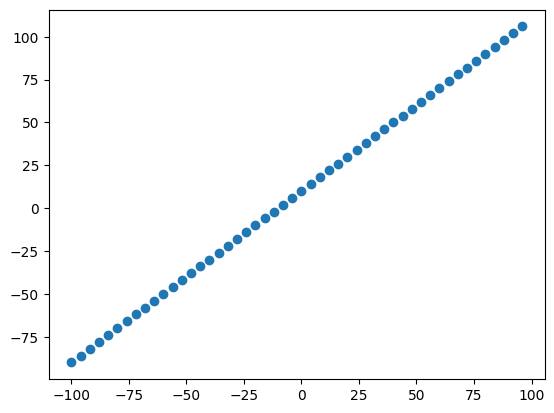

In [43]:
#Visualize the data
import matplotlib.pyplot as plt

plt.scatter(X,y)

In [44]:
### The 3 sets...

* **Training set** - the model learns from this data, which is typically 70-80% of the total data you have available.
* **validation set** - the model get tuned on this data, which is typically 10-15% of the data available.
* **Test set** - the model gets evaluated on this data to test what it has learned, this set is typically 10-15% of the total data available.

In [45]:
# Check the length of how many samples we have
len(X)


50

In [46]:
# Split the data into train and test sets
X_train = X[:40] # first 40 are training samples (80% of the data)
y_train = y[:40]

X_test = X[40:] # last 10 are testing samples (20% of the data)
y_test = y[40:]

len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

### Visualing the data
Now we've got our data in training and test sets .... let's visualize it again!

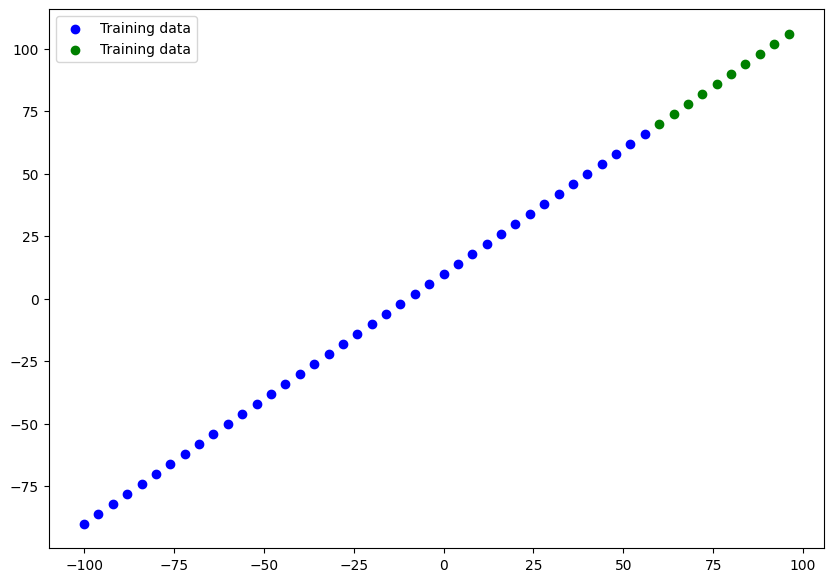

In [47]:
plt.figure(figsize=(10,7))
#Plot training data in blue
plt.scatter(X_train, y_train, c="b", label="Training data")
#Plot test data in green
plt.scatter(X_test, y_test, c="g", label="Training data")
#show a legend
plt.legend();


In [48]:
# Let's create a model which builds automatically by defining the input_shape argument
tf.random.set_seed(42)
#Create a model (same as above)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])


# Reshaped
X_train =tf.expand_dims(X_train, axis=-1)

# 3 Fit the model
model.fit(X_train, y_train, epochs=100)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 56.9531 - mae: 56.9531 
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 22.5695 - mae: 22.5695
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10.0282 - mae: 10.0282
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 11.7219 - mae: 11.7219
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - loss: 8.6692 - mae: 8.6692
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 10.1380 - mae: 10.1380
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 11.8675 - mae: 11.8675 
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.7790 - mae: 8.7790
Epoch 9/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10.2477 - mae: 10.2477
Epoch 10/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 12.0301 - mae: 12.0301
Epoch 11/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 12.6076 - mae: 12.6076
Epoch 12/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 8.1298 - mae: 8.1298
Epoch 13/100
2/2 ━━━━━━━━━

### Visualize the model

In [49]:
# Let's create a model which builds automatically by defining the input_shape argument
tf.random.set_seed(42)
#Create a model (same as above)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, input_shape=[1], name="input_layer"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="model_1...")

# 2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
model.summary()

Model: "model_1..."

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

* Total params - total number of parameters in the model.
* Trainable parameters - these are the parameters (patterns) the model can update as it trains.
* Non-trainable params - these parameters aren't updated during training (this is typical when you bring in already learn patterns or parameters from other models during ***transfer learning**

**Resource: For a more in-deth overview of the trainable parameters within a layer, check out MIT's introduction to deep learning video.
https://www.bing.com/videos/riverview/relatedvideo?q=mit+deep+learning+video&&mid=B38BF986D8171C85F632B38BF986D8171C85F632&FORM=VAMGZC

In [ ]:
model.fit(X_train, y_train, epochs=100, verbose=0)

In [ ]:
# Get a summary of our model
model.summary()

In [ ]:
from tensorflow.keras.utils import plot_model

In [ ]:
plot_model(model=model, show_shapes=True)

### Visualizing our model's predictions

To visualize the model predictions, it's a good idea to plot them against the ground truth labels

Often you'll see this in the form of **y_test** or **y_true**  versus **y_pred** (ground truth versus your models)

In [ ]:
# Make some predictions
y_pred =model.predict(X_test)
y_pred

In [ ]:
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

In [ ]:
y_test

✅**Note:** if you feel like youre going to reuse some kind of functionality in the future, it's a good idea to turn it into a function.

In [ ]:
# let's create a plotting function
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     prediction=y_pred):
 """
 Plots training data, test data and compares predictions to ground truth labels
 """
 plt.figure(figsize=(10,7))
 #Plot training data in blue
 plt.scatter(train_data,train_labels, c="b",label="Training data")
 #Plot testing data in green
 plt.scatter(test_data,test_labels,c="g", label="Testing data")
 #Plot mode's predictions
 plt.scatter(test_data,prediction,c="r",label="predictions")
 #Show the legend
 plt.legend();

In [ ]:
plot_predictions()

### Evaluating our model's predictions with regression evaluation metrics

Depending on the problem you'are working on, there will be different evaluation to evaluate your model's performance.

Since we're working on a regression, two of the main metrics:
* MAE - mean absolute error, "on average, how wrong is each of my model's predictions"
* MSE - mean squre error, "square the average errors"

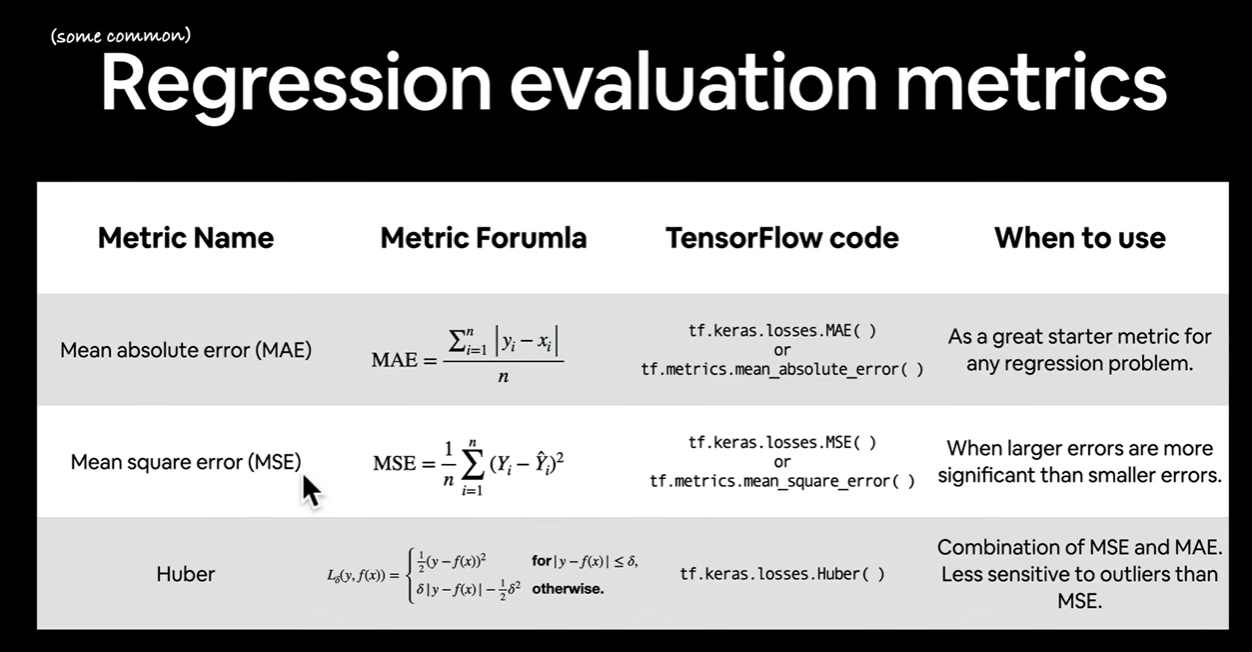

In [ ]:
#Evaluate the model on the test
model.evaluate(X_test, y_test)

In [ ]:
# Calculate the mean absolute error
mae = tf.keras.losses.mae(y_test, y_pred)
mae

In [ ]:
tf.constant(y_pred)

In [ ]:
tf.squeeze(y_pred)

In [ ]:
#calculate the mean the absolute error
mae =tf.keras.losses.mae(y_true=y_test,
                         y_pred=tf.squeeze(y_pred))
mae

In [ ]:
# Calculate the mean Square error
mse = tf.keras.losses.mse(y_true=y_test,y_pred=tf.squeeze(y_pred))
mse

In [ ]:
huber_loss_fn = tf.keras.losses.Huber()
huber = huber_loss_fn(y_true=y_test, y_pred=tf.squeeze(y_pred))
huber

In [ ]:
# Make some functions to reuse MAE and MSE
def mae(y_true,y_pred):
  return tf.keras.losses.mae(y_true=y_true,y_pred=tf.squeeze(y_pred))
def mse(y_true,y_pred):
  return tf.keras.lossess.mse(y_true=y_true,y_pred=tf.squeeze(y_pred))

### Running experiments to improve our model

Build a model -> fit it -> evaluate it -> tweak it -> fit it -> tweak it -> fit it -> evaluate it .....

1. get more data - get more examples for your model to train on (more opportunities to learn patterns or relationships between features and labels).
2. Make your model larger (using a complex model) - this might come in the form of more layers or more hidden units in each layer.
3. Train for longer - give your model more of a chance to find pattern in the data

let's do 3 modelling experiments:
1. 'model_1' - same as the original model, 1 layer, trained for 100 epochs
2. 'model_2' - 2 layers, trained for 100 epochs
3. 'model_3' - 2 layers, trained for 500 epochs


Build model_1

In [ ]:
X_train, y_train

In [ ]:
#set random seed
tf.random.set_seed(42)

#1. Create a model
model_1 =tf.keras.Sequential([
    tf.keras.layers.Dense(1, input_shape=[1]) # Explicitly define input shape
])
# 2. Compile the model
model_1.compile(loss=tf.keras.losses.mae,
               optimizer=tf.keras.optimizers.SGD(),
               metrics=["mae"]
)

# Reshape X_train to be 2-dimensional (samples, features)
X_train_reshaped = tf.expand_dims(X_train, axis=-1)

model_1.fit(X_train_reshaped, y_train, epochs=100)

In [ ]:
# make and plot predictions for model_1
y_preds_1 = model_1.predict(X_test)
plot_predictions(prediction=y_preds_1)

In [ ]:
# Calculate model_1 evaluation metricx
mae_1 =tf.keras.losses.mae(y_test, y_preds_1)
mse_1=tf.keras.losses.mse(y_test, y_preds_1)

mae_1, mse_1


** 'Build model_2' **
* 2 dense layers, trained for 100 epochs

In [ ]:
# set the random seed
tf.random.set_seed(42)
model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Reshape X_train to be 2-dimensional (samples, features)
#X_train_reshaped = tf.expand_dims(X_train, axis=-1)

# Compile the model
model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
                metrics=["mse"])
# 3 fit the model
model_2.fit(X_train, y_train, epochs=100)

In [ ]:
# Make and plot predictions of model

y_preds_2 = model_2.predict(X_test)
plot_predictions(prediction=y_preds_2)

In [ ]:
# Calculate model_2 evaluation metrics
mae_2 = tf.keras.losses.mae(X_test, y_preds_2)
mse_2 = tf.keras.losses.mse(X_test, y_preds_2)
mae_2, mse_2

**Build model_3**

*2 layers, trained for 500 epochs

In [ ]:
# 1.  Set the random seed
tf.random.set_seed(42)

# Create the model
model_3 =tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2 Compiling the model
model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.SGD(),
                metrics=["mae"])

# Fit the model
model_3.fit(X_train,y_train, epochs=500)


Epoch 1/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 38.3473 - mae: 38.3473 
Epoch 2/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 28.3657 - mae: 28.3657
Epoch 3/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 24.3362 - mae: 24.3362
Epoch 4/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 23.8036 - mae: 23.8036
Epoch 5/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 15.1981 - mae: 15.1981
Epoch 6/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 19.3716 - mae: 19.3716
Epoch 7/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 13.8548 - mae: 13.8548
Epoch 8/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 15.0494 - mae: 15.0494
Epoch 9/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 15.8056 - mae: 15.8056
Epoch 10/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 11.8216 - mae: 11.8216
Epoch 11/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 14.7887 - mae: 14.7887
Epoch 12/500
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 10.8732 - mae: 10.8732
Epoch 13/500
2/2 ━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


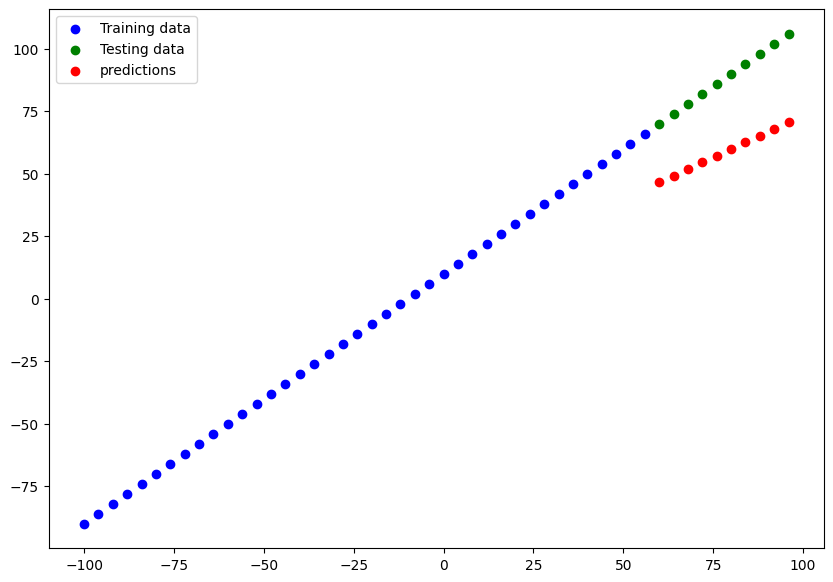

In [ ]:
# Make and plot the predictions

y_preds_3 = model_3.predict(X_test)
plot_predictions(prediction=y_preds_3)

In [ ]:
# Calculate the model 3 evaluation metrics

mae_3 =tf.keras.losses.mae(X_test,y_preds_3)
mse_3 =tf.keras.losses.mse(X_test,y_preds_3)
mae_3, mse_3

(<tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([13.470978, 14.80307 , 16.135159, 17.467243, 18.799335, 20.13142 ,
        21.463505, 22.795593, 24.127686, 25.459778], dtype=float32)>,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([181.46724, 219.13089, 260.34335, 305.10458, 353.415  , 405.27408,
        460.68204, 519.6391 , 582.1452 , 648.2003 ], dtype=float32)>)

**Note:** You want to start with small experiments (small models and make sure they work and then increase their scale when necessary)

### Comparing the results of our experiments

We've run a few experiments, let's compare the results

In [ ]:
# Lets compare our model's results using a pandas DataFrame
import pandas as pd
model_results = [["model_1", mae_1.numpy(),mse_1.numpy()],
                 ["model_2", mae_2.numpy(), mse_2.numpy()],
                 ["model_3", mae_3.numpy(), mse_3.numpy()]]

all_results = pd.DataFrame(model_results, columns=["model", "mae"," mse"])

all_results



,model,mae,mse
0,model_1,"[6.8231163, 6.703697, 6.584282, 6.4648666, 6.3...","[46.554916, 44.939556, 43.352768, 41.794502, 4..."
1,model_2,"[12.060898, 12.168465, 12.276024, 12.383598, 1...","[145.46526, 148.07153, 150.70076, 153.3535, 15..."
2,model_3,"[13.470978, 14.80307, 16.135159, 17.467243, 18...","[181.46724, 219.13089, 260.34335, 305.10458, 3..."


It looks like the model_2 perform the best

In [ ]:
model_2.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

> ☝ **Note:** One of your main goals should be to minimize the time between your experiments. The more experiments the more things you will figure out which don't work and in turn, get closer to figure out what does work. Remember the machine learning practioner's motto: 'experiment, experiment, experiment.

## Tracking your experiments

One really good habit in machine learning modelling is to track the results of your experiments.

And when doing so, it can be tedious if you'are running lots of experiments.

Luckily, there are tools to help us!
🌳**Resource:** As you build more models, you'll want to look into using:

* TensorBoard - a component of the TensorFlow library to help track modelling experiment (we'll see this one latter).

* Weights & Biases - a tool for tracking all of kinds of machine learning experiments (plugs straight into TensorBoard)


**HOW TO SAVE A TENSORFLOW MODEL**
Saving our models allows us to use them outside of Google colab (or where they train

There are two main formats we can save our model's too:

1. The SavedModel format
2. The HDF5 format

In [ ]:
# Save model using the savedmodel format
model_2.save("best_model_SaveModel_format.keras")

In [ ]:
model_2.save("best_model_HDF5_format.h5")

### How to load and use A saved Tensorflow model

In [ ]:
# Load the savedmodel format model
loaded_savedmodel_format =tf.keras.models.load_model("/content/best_model_SaveModel_format.keras")
loaded_savedmodel_format.summary()



Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

In [ ]:
# Compare model_2 predictions with SavedModel format predictions
models_2_preds = model_2.predict(X_test)
loaded_savedmodel_format_preds = loaded_savedmodel_format.predict(X_test)
models_2_preds == loaded_savedmodel_format_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [ ]:
# Load in a model using the .h5 format
loaded_h5_model = tf.keras.models.load_model("/content/best_model_HDF5_format.h5")
loaded_h5_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (136.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
# check the prediction to see if loaded .h5 model predictions match
loaded_h5_preds = model_2.predict(X_test)
loaded_h5_model_preds =loaded_h5_model.predict(X_test)

loaded_h5_preds == loaded_h5_model_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True],
       [ True]])

## Download a model (or any other file ) from Google Colab

1 You can go to the "files" tab and right click on the file you're after and click "download".

2. Use code (see the cell below)

In [ ]:
# Download a file from Google Colab
from google.colab import files
files.download("/content/best_model_HDF5_format.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save a file from Google Colab to Google Drive
!cp /content/best_model_HDF5_format.h5 /content/drive/MyDrive/TensorFlow_Course

In [ ]:
!ls /content/drive/MyDrive/TensorFlow_Course

/content/drive/MyDrive/TensorFlow_Course


## **A larger example**

In [1]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Read in the insurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
# Let's try one-hot encode our DataFrame so it's all numbers
insurance_one_hot = pd.get_dummies(insurance)
insurance_one_hot.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [4]:
# Create X & y values (features and labels)
X = insurance_one_hot.drop("charges", axis=1)
y = insurance_one_hot["charges"]

In [5]:
X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,True,False,False,True,False,False,False,True
1,18,33.770,1,False,True,True,False,False,False,True,False
2,28,33.000,3,False,True,True,False,False,False,True,False
3,33,22.705,0,False,True,True,False,False,True,False,False
4,32,28.880,0,False,True,True,False,False,True,False,False


In [6]:
y.head()

,charges
0,16884.92400
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520


In [7]:
len(X), len(y)

(1338, 1338)

In [8]:
#Create training and test sets using sklearn
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X), len(X_train), len(X_test), len(y), len(y_train), len(y_test)

(1338, 1070, 268, 1338, 1070, 268)

In [9]:
# Build a neural network (sort of like model_2 above)
tf.random.set_seed(42)

# 1. Create a model
insurance_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2 Compile the model
insurance_model.compile(loss=tf.keras.losses.mae,
                        optimizer = tf.keras.optimizers.SGD(),
                        metrics=["mae"])
# 3 Fit the model
insurance_model.fit(X_train, y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 10085.7900 - mae: 10085.7900
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7732.9849 - mae: 7732.9849
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7899.3945 - mae: 7899.3945
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7435.6816 - mae: 7435.6816
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7310.1934 - mae: 7310.1934
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7278.4751 - mae: 7278.4751
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7835.8940 - mae: 7835.8940
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7360.0864 - mae: 7360.0864
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 7267.4170 - mae: 7267.4170
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 7579.5317 - mae: 7579.5317
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 7792.6650 - mae: 7792.6650
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms

In [10]:
# check the results of the insurance model on the test data
insurance_model.evaluate(X_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 6232.7324 - mae: 6232.7324  


[6091.10009765625, 6091.10009765625]

Right now it looks like our model isn't performing too well...let's try and improve it!

**IMPROVING OUR REGRESSION MODEL**
TO (Try) improve our model, we'll run 2 experiments:
1. Add an extra layer with more hidden units and use the Adam optimizer
2. Same as above but train for longer for longer (200 epochs)
3. insert your own experiment here

In [11]:
# set the random seed
tf.random.set_seed(42)

# 1. Create a model
insurance_model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model
insurance_model_1.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])
# 3. Fit the model
insurance_model_1.fit(X_train,y_train, epochs=100, verbose=1)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 13271.4590 - mae: 13271.4590
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13132.2773 - mae: 13132.2773
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12842.4209 - mae: 12842.4209
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12253.9326 - mae: 12253.9326
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11218.7070 - mae: 11218.7070
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9785.3740 - mae: 9785.3740
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8337.3438 - mae: 8337.3438
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7503.9058 - mae: 7503.9058
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7363.9575 - mae: 7363.9575
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7337.4561 - mae: 7337.4561
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7316.6870 - mae: 7316.6870
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s

In [12]:
# Evaluate the model
insurance_model_1.evaluate(X_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5030.4380 - mae: 5030.4380  


[4881.55908203125, 4881.55908203125]

In [13]:
# Set the random seed
tf.random.set_seed(42)

# 1. Create a model
insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# 2. Compile the model

insurance_model_2.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])
# 3. Fit the model
history = insurance_model_2.fit(X_train,y_train, epochs=200)

Epoch 1/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 13262.4844 - mae: 13262.4844
Epoch 2/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13077.9336 - mae: 13077.9336
Epoch 3/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12711.4082 - mae: 12711.4082
Epoch 4/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12004.6738 - mae: 12004.6738
Epoch 5/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10845.6699 - mae: 10845.6699
Epoch 6/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9392.0068 - mae: 9392.0068
Epoch 7/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8084.0762 - mae: 8084.0762
Epoch 8/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7479.8540 - mae: 7479.8540
Epoch 9/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7391.5874 - mae: 7391.5874
Epoch 10/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7366.4365 - mae: 7366.4365
Epoch 11/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7344.4229 - mae: 7344.4229
Epoch 12/200
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s

In [14]:
insurance_model_2.evaluate(X_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3459.4797 - mae: 3459.4797  


[3394.574951171875, 3394.574951171875]

Text(0.5, 0, 'epochs')

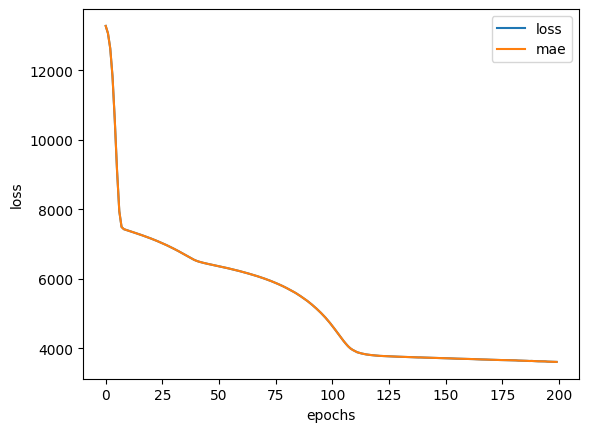

In [15]:
# Plot history (also known as a loss curve or a training curve)
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")

> 💁**Question:** How long should you train for?
It depends. Really... it depends on the problem you're working on. However, many people have asked this question before...so TensorFlow has a solution! it's called the [EarlyStopping callback](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping), which is a TensorFlow component you can add to your model to stop training once it stop improving a certain metric

## **Preprocessing data(normalization and Standardization)**

In terms of scaling values, neural networks tend to prefer normalization

if you're not sure on which to use, you could try both and see which performs better.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
# Read in the insurance dataset
insurance = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
insurance

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


##To prepare our data, we can borrow a few classess from Scikit-learn

In [17]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Create a column transformer
ct = make_column_transformer(
    (MinMaxScaler(),["age","bmi","children"]), # turn all values in these columns between 0 and 1
    (OneHotEncoder(handle_unknown="ignore"),["sex", "smoker","region"])

)
# Create X & y
X = insurance.drop("charges", axis=1)
y = insurance["charges"]

# Build our train and test sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# Fit the column transformer to our training data
ct.fit(X_train)

# Transform training and test data with mormalization (MinMaxScaler) and OneHotEncoder)
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)

In [18]:
# what does our data look like now?
X_train.loc[0]

,0
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest


In [19]:
X_train_normal.shape

(1070, 11)

##Beautiful! Our data has been normalized and one hot encoded.

Now let's build a neural network model on it and see how it goes.


In [20]:
# Build a neural network model to fit on our normalized data

# Set the random set
tf.random.set_seed(42)

# 1. Create the model
insurance_model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)

])

# 2. Compile the model
insurance_model_3.compile(loss=tf.keras.losses.mae,
                          optimizer=tf.keras.optimizers.Adam(),
                          metrics=["mae"])

# 3 Fit the model
insurance_model_3.fit(X_train_normal,y_train, epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 13297.6104 - mae: 13297.6104
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13291.3701 - mae: 13291.3701
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13275.7500 - mae: 13275.7500
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13240.6152 - mae: 13240.6152
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13174.8037 - mae: 13174.8037
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13066.9941 - mae: 13066.9941
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12906.3496 - mae: 12906.3496
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12682.5723 - mae: 12682.5723
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12385.7344 - mae: 12385.7344
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12007.4170 - mae: 12007.4170
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11553.3516 - mae: 11553.3516
Epoch 12/100
34/34 ━━━━━━━━━━━

In [21]:
# Evaluate our insurance model trained on normalized data
insurance_model_3.evaluate(X_test_normal,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3518.6895 - mae: 3518.6895  


[3432.878173828125, 3432.878173828125]

<Axes: ylabel='Frequency'>

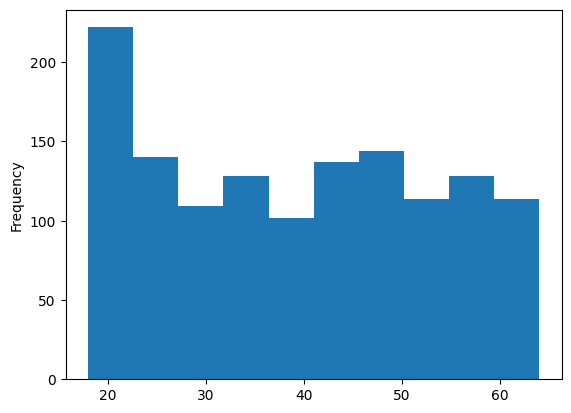

In [22]:
X["age"].plot(kind="hist")

<Axes: ylabel='Frequency'>

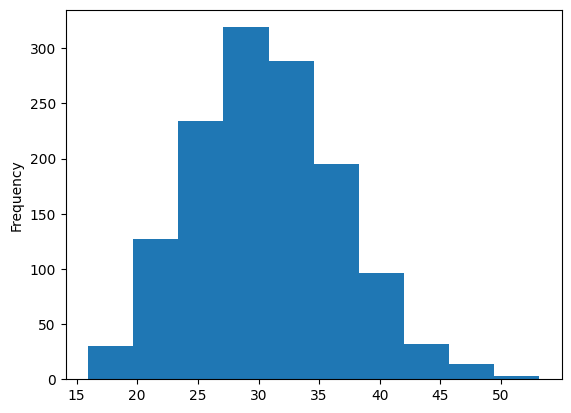

In [23]:
X["bmi"].plot(kind="hist")